In [8]:
print("ram ram")

ram ram


In [9]:
import os
from dotenv import load_dotenv

load_dotenv()

USERNAME = os.getenv("KNX_USERNAME")
PASSWORD = os.getenv("KNX_PASSWORD")
BASE_KNX_IP = os.getenv("BASE_KNX_IP")

In [10]:
import os
from dotenv import load_dotenv
from influxdb_client import InfluxDBClient

load_dotenv(override=True)

INFLUX_URL = os.getenv("INFLUXDB_URL")
INFLUX_TOKEN = os.getenv("INFLUXDB_TOKEN", "")
INFLUX_ORG = os.getenv("INFLUXDB_ORG")
INFLUX_BUCKET = os.getenv("INFLUXDB_BUCKET", "ECE2")
TELEMETRY_RANGE = os.getenv("INFLUX_TELEMETRY_RANGE", "30d")

if not all([INFLUX_URL, INFLUX_ORG, INFLUX_BUCKET]):
    raise ValueError("Check InfluxDB URL, organization and bucket in .env")

if not INFLUX_TOKEN:
    raise ValueError(
        "INFLUXDB_TOKEN is empty. Configure a valid token if authentication "
        "is enabled on your InfluxDB server."
    )

client = InfluxDBClient(
    url=INFLUX_URL,
    token=INFLUX_TOKEN,
    org=INFLUX_ORG,
    timeout=30000
)

query_api = client.query_api()

print("InfluxDB client initialized")
print("URL:", INFLUX_URL)
print("Organization:", INFLUX_ORG)
print("Bucket:", INFLUX_BUCKET)
print("Historical range:", TELEMETRY_RANGE)

InfluxDB client initialized
URL: http://192.168.10.130:8086
Organization: IIIOT-INFOTECH
Bucket: ECE2
Historical range: 30d


In [12]:
flux = f'''
from(bucket: "{INFLUX_BUCKET}")
    |> range(start: -{TELEMETRY_RANGE})
    |> filter(fn: (r) =>
        r._measurement == "electrical_params"
    )
    |> filter(fn: (r) =>
        r._field == "BN_V" or
        r._field == "BR_V" or
        r._field == "RN_V" or
        r._field == "RY_V" or
        r._field == "YN_V" or
        r._field == "YB_V" or
        r._field == "R_Current" or
        r._field == "Y_Current" or
        r._field == "B_Current" or
        r._field == "V_AVG" or
        r._field == "Current_AVG" or
        r._field == "Temperature" or
        r._field == "Vibration" or
        r._field == "Cumulative_Cycles"
    )
    |> pivot(
        rowKey: ["_time"],
        columnKey: ["_field"],
        valueColumn: "_value"
    )
    |> sort(columns: ["_time"])
'''

raw = query_api.query_data_frame(flux, org=INFLUX_ORG)

if isinstance(raw, list):
    import pandas as pd
    raw = pd.concat(raw, ignore_index=True)

print("Rows:", len(raw))
print("Columns:", raw.columns.tolist())
display(raw.head())

Rows: 684201
Columns: ['result', 'table', '_start', '_stop', '_time', '_measurement', 'BN_V', 'BR_V', 'B_Current', 'Current_AVG', 'RN_V', 'RY_V', 'R_Current', 'Temperature', 'V_AVG', 'YB_V', 'YN_V', 'Y_Current', 'device_id', 'Cumulative_Cycles', 'Vibration']


,result,table,_start,_stop,_time,_measurement,BN_V,BR_V,B_Current,Current_AVG,...,RY_V,R_Current,Temperature,V_AVG,YB_V,YN_V,Y_Current,device_id,Cumulative_Cycles,Vibration
0,_result,0,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-09-10 05:51:33.008000+00:00,electrical_params,184.0,347.0,5.2,6.5,...,347.0,8.0,43.6,337.0,318.0,184.0,6.3,NaN,NaN,NaN
1,_result,0,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-09-10 05:51:38.011000+00:00,electrical_params,184.0,346.0,5.2,6.4,...,347.0,8.0,43.7,337.0,319.0,185.0,6.2,NaN,NaN,NaN
2,_result,0,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-09-10 05:51:43.004000+00:00,electrical_params,184.0,345.0,5.2,6.4,...,345.0,7.9,43.6,336.0,318.0,184.0,6.3,NaN,NaN,NaN
3,_result,0,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-09-10 05:51:48.007000+00:00,electrical_params,185.0,346.0,5.2,6.4,...,346.0,7.9,43.7,337.0,320.0,185.0,6.3,NaN,NaN,NaN
4,_result,0,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-09-10 05:51:53.003000+00:00,electrical_params,185.0,346.0,5.2,6.5,...,346.0,8.0,43.8,337.0,320.0,185.0,6.3,NaN,NaN,NaN


In [13]:
display(raw)

,result,table,_start,_stop,_time,_measurement,BN_V,BR_V,B_Current,Current_AVG,...,RY_V,R_Current,Temperature,V_AVG,YB_V,YN_V,Y_Current,device_id,Cumulative_Cycles,Vibration
0,_result,0,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-09-10 05:51:33.008000+00:00,electrical_params,184.0,347.0,5.2,6.5,...,347.0,8.0,43.6,337.0,318.0,184.0,6.3,NaN,NaN,NaN
1,_result,0,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-09-10 05:51:38.011000+00:00,electrical_params,184.0,346.0,5.2,6.4,...,347.0,8.0,43.7,337.0,319.0,185.0,6.2,NaN,NaN,NaN
2,_result,0,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-09-10 05:51:43.004000+00:00,electrical_params,184.0,345.0,5.2,6.4,...,345.0,7.9,43.6,336.0,318.0,184.0,6.3,NaN,NaN,NaN
3,_result,0,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-09-10 05:51:48.007000+00:00,electrical_params,185.0,346.0,5.2,6.4,...,346.0,7.9,43.7,337.0,320.0,185.0,6.3,NaN,NaN,NaN
4,_result,0,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-09-10 05:51:53.003000+00:00,electrical_params,185.0,346.0,5.2,6.5,...,346.0,8.0,43.8,337.0,320.0,185.0,6.3,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
684196,_result,2,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-10-01 06:54:01.496000+00:00,electrical_params,247.0,425.0,0.8,0.7,...,418.0,0.4,34.7,421.0,420.0,239.0,0.9,012ZY5SC,NaN,5.195711
684197,_result,2,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-10-01 06:54:01.668000+00:00,electrical_params,247.0,425.0,0.8,0.7,...,418.0,0.4,34.7,421.0,420.0,239.0,0.9,012ZY5SC,NaN,5.195711
684198,_result,2,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-10-01 06:54:01.781000+00:00,electrical_params,247.0,425.0,0.8,0.7,...,418.0,0.4,34.7,421.0,420.0,239.0,0.9,012ZY5SC,NaN,5.195711
684199,_result,2,2026-09-01 07:18:05.651747+00:00,2026-10-01 07:18:05.651747+00:00,2026-10-01 06:54:02.680000+00:00,electrical_params,247.0,425.0,0.8,0.7,...,418.0,0.4,34.7,421.0,420.0,239.0,0.9,012ZY5SC,NaN,5.195711


In [14]:
sample_flux = f'''
from(bucket: "{INFLUX_BUCKET}")
    |> range(start: -1h)
    |> filter(fn: (r) => r._measurement == "electrical_params")
    |> limit(n: 10)
'''

sample = query_api.query_data_frame(
    sample_flux,
    org=INFLUX_ORG
)

display(sample)

C:\Users\soroj\OneDrive\Desktop\IIIOT Activate Projects\MANUFACTURING-AGENTIC-AI\backend\venv\Lib\site-packages\influxdb_client\client\warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
from(bucket: "ECE2")
    |> range(start: -1h)
    |> filter(fn: (r) => r._measurement == "electrical_params")
    |> limit(n: 10)
 |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")

You can disable this warning by:
    import warnings
    from influxdb_client.client.warnings import MissingPivotFunction

    warnings.simplefilter("ignore", MissingPivotFunction)

For more info see:
    - https://docs.influxdata.com/resources/videos/pivots-in-flux/
    - https://docs.influxdata.com/flux/latest/stdlib/universe/pivot/
    - https://docs.influxdata.com/flux/latest/stdlib/influxdata/influxdb/schema/fieldsascols/

  warnings.warn(message, Missing

,result,table,_start,_stop,_time,_value,_field,_measurement,device_id
0,_result,0,2026-10-01 06:24:50.626389+00:00,2026-10-01 07:24:50.626389+00:00,2026-10-01 06:24:50.963000+00:00,180.0,BN_V,electrical_params,00WH9OUI
1,_result,0,2026-10-01 06:24:50.626389+00:00,2026-10-01 07:24:50.626389+00:00,2026-10-01 06:24:53.063000+00:00,183.0,BN_V,electrical_params,00WH9OUI
2,_result,0,2026-10-01 06:24:50.626389+00:00,2026-10-01 07:24:50.626389+00:00,2026-10-01 06:24:54.957000+00:00,184.0,BN_V,electrical_params,00WH9OUI
3,_result,0,2026-10-01 06:24:50.626389+00:00,2026-10-01 07:24:50.626389+00:00,2026-10-01 06:24:56.957000+00:00,183.0,BN_V,electrical_params,00WH9OUI
4,_result,0,2026-10-01 06:24:50.626389+00:00,2026-10-01 07:24:50.626389+00:00,2026-10-01 06:24:58.958000+00:00,180.0,BN_V,electrical_params,00WH9OUI
...,...,...,...,...,...,...,...,...,...
295,_result,29,2026-10-01 06:24:50.626389+00:00,2026-10-01 07:24:50.626389+00:00,2026-10-01 06:25:00.672000+00:00,0.9,Y_Current,electrical_params,012ZY5SC
296,_result,29,2026-10-01 06:24:50.626389+00:00,2026-10-01 07:24:50.626389+00:00,2026-10-01 06:25:02.679000+00:00,0.9,Y_Current,electrical_params,012ZY5SC
297,_result,29,2026-10-01 06:24:50.626389+00:00,2026-10-01 07:24:50.626389+00:00,2026-10-01 06:25:04.664000+00:00,0.9,Y_Current,electrical_params,012ZY5SC
298,_result,29,2026-10-01 06:24:50.626389+00:00,2026-10-01 07:24:50.626389+00:00,2026-10-01 06:25:06.671000+00:00,0.9,Y_Current,electrical_params,012ZY5SC


In [15]:
sample_flux = f'''
from(bucket: "{INFLUX_BUCKET}")
    |> range(start: -1h)
    |> filter(fn: (r) => r._measurement == "electrical_params")
    |> limit(n: 10)
'''

sample = query_api.query_data_frame(sample_flux, org=INFLUX_ORG)

if isinstance(sample, list):
    for i, df in enumerate(sample):
        print(f"\nTable {i}:")
        print(df.columns.tolist())
        display(df.head())
else:
    print(sample.columns.tolist())
    display(sample.head())

['result', 'table', '_start', '_stop', '_time', '_value', '_field', '_measurement', 'device_id']


C:\Users\soroj\OneDrive\Desktop\IIIOT Activate Projects\MANUFACTURING-AGENTIC-AI\backend\venv\Lib\site-packages\influxdb_client\client\warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
from(bucket: "ECE2")
    |> range(start: -1h)
    |> filter(fn: (r) => r._measurement == "electrical_params")
    |> limit(n: 10)
 |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")

You can disable this warning by:
    import warnings
    from influxdb_client.client.warnings import MissingPivotFunction

    warnings.simplefilter("ignore", MissingPivotFunction)

For more info see:
    - https://docs.influxdata.com/resources/videos/pivots-in-flux/
    - https://docs.influxdata.com/flux/latest/stdlib/universe/pivot/
    - https://docs.influxdata.com/flux/latest/stdlib/influxdata/influxdb/schema/fieldsascols/

  warnings.warn(message, Missing

,result,table,_start,_stop,_time,_value,_field,_measurement,device_id
0,_result,0,2026-10-01 06:26:35.239141+00:00,2026-10-01 07:26:35.239141+00:00,2026-10-01 06:26:36.958000+00:00,179.0,BN_V,electrical_params,00WH9OUI
1,_result,0,2026-10-01 06:26:35.239141+00:00,2026-10-01 07:26:35.239141+00:00,2026-10-01 06:26:38.959000+00:00,178.0,BN_V,electrical_params,00WH9OUI
2,_result,0,2026-10-01 06:26:35.239141+00:00,2026-10-01 07:26:35.239141+00:00,2026-10-01 06:26:40.958000+00:00,182.0,BN_V,electrical_params,00WH9OUI
3,_result,0,2026-10-01 06:26:35.239141+00:00,2026-10-01 07:26:35.239141+00:00,2026-10-01 06:26:42.957000+00:00,182.0,BN_V,electrical_params,00WH9OUI
4,_result,0,2026-10-01 06:26:35.239141+00:00,2026-10-01 07:26:35.239141+00:00,2026-10-01 06:26:44.957000+00:00,178.0,BN_V,electrical_params,00WH9OUI


In [16]:
import pandas as pd

flux = f'''
from(bucket: "{INFLUX_BUCKET}")
    |> range(start: -{TELEMETRY_RANGE})
    |> filter(fn: (r) => r._measurement == "electrical_params")
    |> filter(fn: (r) =>
        r._field == "BN_V" or
        r._field == "BR_V" or
        r._field == "RN_V" or
        r._field == "RY_V" or
        r._field == "YN_V" or
        r._field == "YB_V" or
        r._field == "R_Current" or
        r._field == "Y_Current" or
        r._field == "B_Current" or
        r._field == "V_AVG" or
        r._field == "Current_AVG" or
        r._field == "Temperature" or
        r._field == "Vibration" or
        r._field == "Cumulative_Cycles"
    )
    |> keep(columns: ["_time", "_field", "_value", "device_id"])
'''

raw = query_api.query_data_frame(flux, org=INFLUX_ORG)

# The InfluxDB client may return multiple DataFrames.
if isinstance(raw, list):
    raw = pd.concat(raw, ignore_index=True)

# Remove empty results and normalize values.
raw = raw.dropna(subset=["_field", "_value"]).copy()
raw["_value"] = pd.to_numeric(raw["_value"], errors="coerce")
raw = raw.dropna(subset=["_value"])

if "device_id" not in raw.columns:
    raw["device_id"] = "Unknown device"

summary = (
    raw.groupby(["device_id", "_field"])["_value"]
    .agg(["count", "min", "mean", "max", "last"])
    .round(2)
    .reset_index()
)

display(summary)

C:\Users\soroj\OneDrive\Desktop\IIIOT Activate Projects\MANUFACTURING-AGENTIC-AI\backend\venv\Lib\site-packages\influxdb_client\client\warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
from(bucket: "ECE2")
    |> range(start: -30d)
    |> filter(fn: (r) => r._measurement == "electrical_params")
    |> filter(fn: (r) =>
        r._field == "BN_V" or
        r._field == "BR_V" or
        r._field == "RN_V" or
        r._field == "RY_V" or
        r._field == "YN_V" or
        r._field == "YB_V" or
        r._field == "R_Current" or
        r._field == "Y_Current" or
        r._field == "B_Current" or
        r._field == "V_AVG" or
        r._field == "Current_AVG" or
        r._field == "Temperature" or
        r._field == "Vibration" or
        r._field == "Cumulative_Cycles"
    )
    |> keep(columns: ["_time", "_field", "_value", "device_id"

,device_id,_field,count,min,mean,max,last
0,00WH9OUI,BN_V,435982,0.0,187.82,253.00,188.00
1,00WH9OUI,BR_V,435982,0.0,348.10,434.00,348.00
2,00WH9OUI,B_Current,435982,0.0,5.16,11.10,5.50
3,00WH9OUI,Cumulative_Cycles,995,0.0,45.64,128.00,7.00
4,00WH9OUI,Current_AVG,435982,0.0,6.29,14.50,6.50
5,00WH9OUI,RN_V,435982,0.0,214.33,250.00,214.00
6,00WH9OUI,RY_V,435982,0.0,349.33,427.00,348.00
7,00WH9OUI,R_Current,435982,0.0,7.69,16.30,7.90
8,00WH9OUI,Temperature,435982,-129.6,6.28,592.60,34.60
9,00WH9OUI,V_AVG,435982,0.0,340.83,429.00,340.00


In [17]:
data_context = summary.to_string(index=False)

print(data_context[:12000])

device_id            _field  count    min   mean    max   last
 00WH9OUI              BN_V 435982    0.0 187.82 253.00 188.00
 00WH9OUI              BR_V 435982    0.0 348.10 434.00 348.00
 00WH9OUI         B_Current 435982    0.0   5.16  11.10   5.50
 00WH9OUI Cumulative_Cycles    995    0.0  45.64 128.00   7.00
 00WH9OUI       Current_AVG 435982    0.0   6.29  14.50   6.50
 00WH9OUI              RN_V 435982    0.0 214.33 250.00 214.00
 00WH9OUI              RY_V 435982    0.0 349.33 427.00 348.00
 00WH9OUI         R_Current 435982    0.0   7.69  16.30   7.90
 00WH9OUI       Temperature 435982 -129.6   6.28 592.60  34.60
 00WH9OUI             V_AVG 435982    0.0 340.83 429.00 340.00
 00WH9OUI         Vibration 294598    0.0   5.54   9.54   5.53
 00WH9OUI              YB_V 435982    0.0 326.09 439.00 325.00
 00WH9OUI              YN_V 435982    0.0 189.27 255.00 188.00
 00WH9OUI         Y_Current 435982    0.0   6.12  16.30   6.20
 012ZY5SC              BN_V 248395    0.0 250.54 268.00

In [19]:
import os
from dotenv import load_dotenv
from litellm import completion

load_dotenv(override=True)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL", "groq/openai/gpt-oss-20b")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing from your .env file")

ENERGY_AGENT_PROMPT = """
You are Energy Agent, an industrial electrical telemetry assistant.

Your responsibilities:
- Summarize electrical telemetry retrieved from InfluxDB.
- Explain voltage, current, temperature, vibration, and cycle readings.
- Identify potentially unusual readings using the provided data.
- Give practical recommendations based on available evidence.
- Clearly state the device ID and signal name when available.

Rules:
- Use only the supplied telemetry for claims about actual readings.
- Never invent sensor values or claim energy consumption in kWh
  unless a validated energy reading is provided.
- If information is missing, state that explicitly.
- Distinguish observed readings from possible causes.
- Respond professionally and concisely.
"""

def ask_energy_agent(question, data_context):
    response = completion(
        model=GROQ_MODEL,
        api_key=GROQ_API_KEY,
        messages=[
            {"role": "system", "content": ENERGY_AGENT_PROMPT},
            {
                "role": "user",
                "content": (
                    f"Question: {question}\n\n"
                    f"InfluxDB telemetry summary:\n{data_context}"
                )
            }
        ],
        temperature=0.2
    )

    return response.choices[0].message.content

print("Energy Agent initialized successfully.")
print("Model:", GROQ_MODEL)

Energy Agent initialized successfully.
Model: groq/openai/gpt-oss-20b


In [20]:
answer = ask_energy_agent(
    "Summarize the electrical telemetry and identify unusual readings.",
    data_context=data_context
)

print(answer)

**Device 00WH9OUI**

| Signal | Count | Min | Mean | Max | Last |
|--------|-------|-----|------|-----|------|
| BN_V   | 435 982 | 0.0 | 187.82 | 253.00 | 188.00 |
| BR_V   | 435 982 | 0.0 | 348.10 | 434.00 | 348.00 |
| B_Current | 435 982 | 0.0 | 5.16 | 11.10 | 5.50 |
| Current_AVG | 435 982 | 0.0 | 6.29 | 14.50 | 6.50 |
| RN_V   | 435 982 | 0.0 | 214.33 | 250.00 | 214.00 |
| RY_V   | 435 982 | 0.0 | 349.33 | 427.00 | 348.00 |
| R_Current | 435 982 | 0.0 | 7.69 | 16.30 | 7.90 |
| Temperature | 435 982 | –129.6 | 6.28 | 592.60 | 34.60 |
| V_AVG | 435 982 | 0.0 | 340.83 | 429.00 | 340.00 |
| Vibration | 294 598 | 0.0 | 5.54 | 9.54 | 5.53 |
| YB_V   | 435 982 | 0.0 | 326.09 | 439.00 | 325.00 |
| YN_V   | 435 982 | 0.0 | 189.27 | 255.00 | 188.00 |
| Y_Current | 435 982 | 0.0 | 6.12 | 16.30 | 6.20 |

**Device 012ZY5SC**

| Signal | Count | Min | Mean | Max | Last |
|--------|-------|-----|------|-----|------|
| BN_V   | 248 395 | 0.0 | 250.54 | 268.00 | 247.00 |
| BR_V   | 248 395 | 0.0 |

In [22]:
import os
import json
from collections import defaultdict
from datetime import datetime, timezone

from dotenv import load_dotenv
from influxdb_client import InfluxDBClient
from litellm import Router, completion

load_dotenv(override=True)

GEMINI_KEY = os.getenv("GEMINI_API_KEY")
GEMINI_MODEL = os.getenv(
    "GEMINI_MODEL", "gemini/gemini-3.5-flash"
)

GROQ_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv(
    "GROQ_MODEL", "groq/openai/gpt-oss-20b"
)

GATEWAY_URL = os.getenv("LITELLM_GATEWAY_URL", "").strip()
GATEWAY_KEY = os.getenv("LITELLM_GATEWAY_KEY", "").strip()
GATEWAY_MODEL = os.getenv(
    "LITELLM_GATEWAY_MODEL", "energy-agent"
)

# Reuse your existing working connection if one exists.
if "query_api" not in globals():
    influx_url = os.getenv("INFLUXDB_URL")
    influx_token = os.getenv("INFLUXDB_TOKEN")
    influx_org = os.getenv("INFLUXDB_ORG")

    if not all([influx_url, influx_token, influx_org]):
        raise ValueError(
            "Configure INFLUXDB_URL, INFLUXDB_TOKEN and "
            "INFLUXDB_ORG in .env"
        )

    influx_client = InfluxDBClient(
        url=influx_url,
        token=influx_token,
        org=influx_org,
        timeout=30000,
    )
    query_api = influx_client.query_api()

INFLUX_ORG = os.getenv("INFLUXDB_ORG", "IIIOT-INFOTECH")
INFLUX_BUCKET = os.getenv("INFLUXDB_BUCKET", "ECE2")

# Configure local LiteLLM Router unless using a gateway.
if not (GATEWAY_URL and GATEWAY_KEY):
    model_list = []
    fallback_list = []

    if GEMINI_KEY:
        model_list.extend([
            {
                "model_name": "gemini-primary",
                "litellm_params": {
                    "model": GEMINI_MODEL,
                    "api_key": GEMINI_KEY,
                },
            },
            {
                "model_name": "gemini-fallback",
                "litellm_params": {
                    "model": GEMINI_MODEL,
                    "api_key": GEMINI_KEY,
                },
            },
        ])

    if GROQ_KEY:
        model_list.extend([
            {
                "model_name": "groq-primary",
                "litellm_params": {
                    "model": GROQ_MODEL,
                    "api_key": GROQ_KEY,
                },
            },
            {
                "model_name": "groq-fallback",
                "litellm_params": {
                    "model": GROQ_MODEL,
                    "api_key": GROQ_KEY,
                },
            },
        ])

    if not model_list:
        raise ValueError(
            "Configure GEMINI_API_KEY or GROQ_API_KEY in .env"
        )

    if GEMINI_KEY and GROQ_KEY:
        fallback_list = [
            {"gemini-primary": ["groq-fallback"]},
            {"groq-primary": ["gemini-fallback"]},
        ]

    llm_router = Router(
        model_list=model_list,
        fallbacks=fallback_list,
        num_retries=1,
        timeout=45,
    )

    print("LLM mode: local LiteLLM Router")
    print("Fallback enabled:", bool(fallback_list))
else:
    llm_router = None
    print("LLM mode: LiteLLM Gateway")
    print("Fallback/routing must be configured on the gateway.")

print("InfluxDB bucket:", INFLUX_BUCKET)

15:26:12 - LiteLLM:WARNING: utils.py:2722 - register_model: model=e75e2c30e10db2726bab8204bb6adb3055fd637d71d32d2f921e02f89227c680 not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info
15:26:12 - LiteLLM:WARNING: utils.py:2722 - register_model: model=d25cf1184ca36f9458e1ab27bca6e71ca6942954fc97bcfcfd265d27c64125b1 not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info
15:26:12 - LiteLLM:WARNING: utils.py:2722 - register_model: model=e2ed5a1489c87d3815cb9b87356f08f38196a8cd461d1e35b26ab0e771928e6b not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_inf

LLM mode: local LiteLLM Router
Fallback enabled: True
InfluxDB bucket: ECE2


In [24]:
from langchain_core.tools import tool

ENERGY_FIELDS = [
    "BN_V", "BR_V", "RN_V", "RY_V", "YN_V", "YB_V",
    "R_Current", "Y_Current", "B_Current",
    "V_AVG", "Current_AVG",
    "Temperature", "Vibration", "Cumulative_Cycles",
]

@tool
def get_influx_telemetry(time_range: str = "24h") -> str:
    """Retrieve and summarize real electrical telemetry from InfluxDB.

    Args:
        time_range: One of 1h, 24h, 7d, or 30d.
    """
    ranges = {
        "1h": ("1h", "1m"),
        "24h": ("24h", "5m"),
        "7d": ("7d", "15m"),
        "30d": ("30d", "1h"),
    }

    if time_range not in ranges:
        return "Invalid time_range. Use 1h, 24h, 7d, or 30d."

    duration, window = ranges[time_range]
    field_list = ", ".join(json.dumps(x) for x in ENERGY_FIELDS)

    flux = f'''
from(bucket: "{INFLUX_BUCKET}")
    |> range(start: -{duration})
    |> filter(fn: (r) =>
        r._measurement == "electrical_params"
    )
    |> filter(fn: (r) =>
        contains(value: r._field, set: [{field_list}])
    )
    |> aggregateWindow(
        every: {window},
        fn: mean,
        createEmpty: false
    )
    |> keep(columns: [
        "_time", "_field", "_value", "device_id"
    ])
    |> sort(columns: ["_time"])
'''

    try:
        tables = query_api.query(flux, org=INFLUX_ORG)
        grouped = defaultdict(list)

        for table in tables:
            for record in table.records:
                value = record.get_value()
                field = record.get_field()
                device = record.values.get("device_id", "Unknown device")
                timestamp = record.get_time()

                if value is None or field is None:
                    continue

                grouped[(str(device), str(field))].append(
                    (timestamp, float(value))
                )

        if not grouped:
            return (
                f"No telemetry found in bucket {INFLUX_BUCKET} "
                f"for the last {time_range}."
            )

        summary = []

        for (device, field), points in sorted(grouped.items()):
            points.sort(key=lambda item: item[0])
            values = [value for _, value in points]

            summary.append({
                "device_id": device,
                "signal": field,
                "unit": (
                    "V" if field.endswith("_V")
                    else "A" if "Current" in field
                    or field.endswith("_Current")
                    else "°C" if field == "Temperature"
                    else "mm/s" if field == "Vibration"
                    else "cycles" if field == "Cumulative_Cycles"
                    else "sensor units"
                ),
                "window_average_count": len(values),
                "min": round(min(values), 3),
                "mean": round(sum(values) / len(values), 3),
                "max": round(max(values), 3),
                "latest_window_average": round(values[-1], 3),
                "latest_window_time": points[-1][0].isoformat(),
            })

        return json.dumps({
            "source": "InfluxDB",
            "bucket": INFLUX_BUCKET,
            "measurement": "electrical_params",
            "requested_range": time_range,
            "aggregation_window": window,
            "data": summary,
            "energy_note": (
                "Exact kWh consumption cannot be established from "
                "these fields alone without a validated energy "
                "counter or power measurement and its sampling details."
            ),
        }, indent=2)

    except Exception as exc:
        return (
            "InfluxDB query failed. Check connectivity, token, "
            f"bucket, measurement, and Flux compatibility. Details: {exc}"
        )

print("InfluxDB tool initialized.")

InfluxDB tool initialized.


In [25]:
from typing import Annotated, TypedDict

from langchain_core.messages import (
    AnyMessage,
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import tool
from langchain_core.utils.function_calling import convert_to_openai_tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode


@tool
def delegate_to_energy_analyst(task: str) -> str:
    """Delegate complex energy analysis to the specialist Energy Analyst.

    Use for deeper analysis of telemetry, comparisons, anomalies,
    possible causes, and recommendations.
    """
    return "Delegation requested."


SYSTEM_PROMPT = """
You are Energy Agent, an industrial electrical telemetry assistant.

You have access to an InfluxDB telemetry tool and an Energy Analyst
specialist.

Rules:
1. Use get_influx_telemetry for questions about actual machine readings,
   voltage, current, temperature, vibration, cycles, or historical trends.
2. Never invent measurements, devices, alerts, or retrieved results.
3. Delegate complex comparisons, anomaly interpretation, or detailed
   recommendations using delegate_to_energy_analyst.
4. Delegate at most once per user turn.
5. Distinguish observed facts from possible explanations.
6. Never claim exact kWh consumption unless validated energy or power
   data is available.
7. Answer clearly and professionally.
"""

ANALYST_PROMPT = """
You are the Energy Analyst specialist working for Energy Agent.

Analyze the user's request and the available InfluxDB tool results.
Explain trends, unusual values, device differences, limitations, and
practical next steps. Do not invent data or treat correlation as proof
of a cause. If the required telemetry is missing, state what is needed.
Return a concise analysis for the main Energy Agent.
"""


class EnergyState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    delegation_count: int


def choose_model(question: str) -> str:
    """Route analytical requests to Gemini and simpler requests to Groq."""
    q = question.lower()

    analytical_terms = [
        "analyze", "analyse", "why", "root cause", "compare",
        "recommend", "trend", "anomaly", "explain", "summary",
        "summarize", "summarise", "historical",
    ]

    prefer_gemini = any(term in q for term in analytical_terms)

    if prefer_gemini and GEMINI_KEY:
        return "gemini-primary"
    if not prefer_gemini and GROQ_KEY:
        return "groq-primary"

    if GEMINI_KEY:
        return "gemini-primary"
    if GROQ_KEY:
        return "groq-primary"

    # Gateway aliases are configured on the gateway itself.
    return GATEWAY_MODEL


def to_openai_messages(messages):
    """Convert LangChain messages into LiteLLM Chat Completions format."""
    converted = []

    for message in messages:
        if isinstance(message, SystemMessage):
            converted.append({
                "role": "system",
                "content": message.content,
            })

        elif isinstance(message, HumanMessage):
            converted.append({
                "role": "user",
                "content": message.content,
            })

        elif isinstance(message, ToolMessage):
            converted.append({
                "role": "tool",
                "tool_call_id": message.tool_call_id,
                "content": str(message.content),
            })

        elif isinstance(message, AIMessage):
            item = {
                "role": "assistant",
                "content": message.content or None,
            }

            if message.tool_calls:
                item["tool_calls"] = [
                    {
                        "id": call["id"],
                        "type": "function",
                        "function": {
                            "name": call["name"],
                            "arguments": json.dumps(call["args"]),
                        },
                    }
                    for call in message.tool_calls
                ]

            converted.append(item)

    return converted


def call_energy_llm(messages, tools=None, question=""):
    """Call either the optional Gateway or the local LiteLLM Router."""
    kwargs = {
        "messages": to_openai_messages(messages),
        "temperature": 0.2,
    }

    if tools:
        kwargs["tools"] = [
            convert_to_openai_tool(tool) for tool in tools
        ]
        kwargs["tool_choice"] = "auto"

    if GATEWAY_URL and GATEWAY_KEY:
        response = completion(
            model=GATEWAY_MODEL,
            api_base=GATEWAY_URL,
            api_key=GATEWAY_KEY,
            **kwargs,
        )
    else:
        response = llm_router.completion(
            model=choose_model(question),
            **kwargs,
        )

    message = response.choices[0].message

    tool_calls = []
    for call in (message.tool_calls or []):
        raw_args = call.function.arguments or "{}"

        try:
            args = json.loads(raw_args)
        except json.JSONDecodeError:
            args = {}

        tool_calls.append({
            "name": call.function.name,
            "args": args,
            "id": call.id,
            "type": "tool_call",
        })

    return AIMessage(
        content=message.content or "",
        tool_calls=tool_calls,
    )


print("Main agent and Energy Analyst configuration ready.")

Main agent and Energy Analyst configuration ready.


In [26]:
def agent_node(state: EnergyState):
    messages = state["messages"]

    latest_question = next(
        (
            str(message.content)
            for message in reversed(messages)
            if isinstance(message, HumanMessage)
        ),
        "",
    )

    available_tools = [get_influx_telemetry]

    # Only offer delegation before the specialist has been called.
    if state.get("delegation_count", 0) < 1:
        available_tools.append(delegate_to_energy_analyst)

    response = call_energy_llm(
        messages=[
            SystemMessage(content=SYSTEM_PROMPT),
            *messages,
        ],
        tools=available_tools,
        question=latest_question,
    )

    return {"messages": [response]}


def route_after_agent(state: EnergyState):
    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tools"

    return END


def route_after_tools(state: EnergyState):
    # Check tool results from the most recent assistant tool-call batch.
    for message in reversed(state["messages"]):
        if isinstance(message, AIMessage):
            break

        if (
            isinstance(message, ToolMessage)
            and message.name == "delegate_to_energy_analyst"
        ):
            return "energy_analyst"

    return "agent"


def energy_analyst_node(state: EnergyState):
    messages = state["messages"]

    latest_question = next(
        (
            str(message.content)
            for message in reversed(messages)
            if isinstance(message, HumanMessage)
        ),
        "",
    )

    analysis = call_energy_llm(
        messages=[
            SystemMessage(content=ANALYST_PROMPT),
            *messages,
        ],
        question=latest_question + " Analyze the available telemetry.",
    )

    # The specialist produces analysis, then control returns to the main agent.
    return {
        "messages": [analysis],
        "delegation_count": state.get("delegation_count", 0) + 1,
    }


builder = StateGraph(EnergyState)

builder.add_node("agent", agent_node)
builder.add_node(
    "tools",
    ToolNode([get_influx_telemetry, delegate_to_energy_analyst]),
)
builder.add_node("energy_analyst", energy_analyst_node)

builder.add_edge(START, "agent")

builder.add_conditional_edges(
    "agent",
    route_after_agent,
    {
        "tools": "tools",
        END: END,
    },
)

builder.add_conditional_edges(
    "tools",
    route_after_tools,
    {
        "agent": "agent",
        "energy_analyst": "energy_analyst",
    },
)

builder.add_edge("energy_analyst", "agent")

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

energy_graph = builder.compile(checkpointer=memory)

print("Energy Agent LangGraph compiled successfully.")

Energy Agent LangGraph compiled successfully.


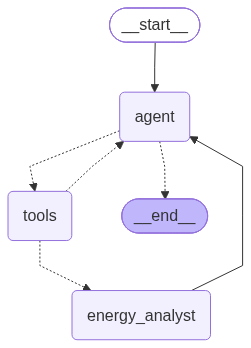

In [27]:
from IPython.display import Image, display

display(
    Image(energy_graph.get_graph().draw_mermaid_png())
)

In [28]:
THREAD_ID = "energy-agent-session-01"

def chat_energy_agent(question: str) -> str:
    result = energy_graph.invoke(
        {
            "messages": [HumanMessage(content=question)],
            "delegation_count": 0,
        },
        config={
            "configurable": {
                "thread_id": THREAD_ID,
            },
            "recursion_limit": 20,
        },
    )

    # Return the latest assistant message.
    for message in reversed(result["messages"]):
        if isinstance(message, AIMessage) and not message.tool_calls:
            if message.content:
                return str(message.content)

    return "The agent completed without producing a final text response."


print(
    chat_energy_agent(
        "Get the last 24 hours of electrical telemetry and summarize "
        "the voltage, current, temperature and vibration readings."
    )
)

**24‑Hour Electrical Telemetry Summary (InfluxDB – ECE2 bucket)**  

| Device | Parameter | Unit | Min | Mean | Max | Latest 5‑min Avg | Latest Timestamp |
|--------|-----------|------|-----|------|-----|------------------|------------------|
| **00WH9OUI** | BN V | V | 179.3 | 185.6 | 218.8 | 182.6 | 2026‑10‑01 09:59:54 |
| | BR V | V | 336.0 | 344.1 | 372.9 | 341.7 | 2026‑10‑01 09:59:54 |
| | B Current | A | 2.10 | 5.35 | 5.60 | 5.15 | 2026‑10‑01 09:59:54 |
| | Current AVG | A | 2.78 | 6.42 | 6.83 | 6.38 | 2026‑10‑01 09:59:54 |
| | RN V | V | 207.3 | 212.0 | 213.7 | 212.0 | 2026‑10‑01 09:59:54 |
| | RY V | V | 338.0 | 345.1 | 376.6 | 343.6 | 2026‑10‑01 09:59:54 |
| | R Current | A | 3.49 | 7.78 | 8.37 | 7.83 | 2026‑10‑01 09:59:54 |
| | Temperature | °C | 26.5 | 32.2 | 35.6 | 35.5 | 2026‑10‑01 09:59:54 |
| | Vibration | mm/s | 5.34 | 5.54 | 5.70 | 5.51 | 2026‑10‑01 09:59:54 |
| **012ZY5SC** | BN V | V | 244.5 | 250.8 | 254.2 | 247.3 | 2026‑10‑01 06:55:00 |
| | BR V | V | 420.1 | 431.4

In [29]:
print("Energy Agent ready. Type 'exit' to stop.")

while True:
    question = input("\nYou: ").strip()

    if question.lower() in {"exit", "quit"}:
        print("Energy Agent: Goodbye.")
        break

    if not question:
        continue

    try:
        print("\nEnergy Agent:", chat_energy_agent(question))
    except Exception as exc:
        print(f"\nAgent error: {exc}")

Energy Agent ready. Type 'exit' to stop.

Energy Agent: Hello! How can I assist you with your telemetry or energy analysis today?


15:31:04 - LiteLLM Router:ERROR: router.py:6327 - litellm.router.py::async_function_with_fallbacks() - Error occurred while trying to do fallbacks - litellm.NotFoundError: GeminiException - {
  "error": {
    "code": 404,
    "message": "This model models/gemini-2.5-flash is no longer available to new users. Please update your code to use models/gemini-3.8-flash for the latest features and improvements. We recommend you to use the Interactions API (https://ai.google.dev/gemini-api/docs/get-started).",
    "status": "NOT_FOUND"
  }
}
No fallback model group found for original model_group=gemini-fallback. Fallbacks=[{'gemini-primary': ['groq-fallback']}, {'groq-primary': ['gemini-fallback']}]
Traceback (most recent call last):
  File "C:\Users\soroj\OneDrive\Desktop\IIIOT Activate Projects\MANUFACTURING-AGENTIC-AI\backend\venv\Lib\site-packages\litellm\llms\vertex_ai\gemini\vertex_and_google_ai_studio_gemini.py", line 3061, in completion
    response = client.post(url=url, headers=header


Agent error: litellm.RateLimitError: RateLimitError: GroqException - {"error":{"message":"Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01kxfj9xj2ewqrbfn3wx5zs7m7` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Used 3524, Requested 5451. Please try again in 7.3125s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing","type":"tokens","code":"rate_limit_exceeded"}}
. Received Model Group=groq-primary
Available Model Group Fallbacks=['gemini-fallback']
Error doing the fallback: litellm.NotFoundError: GeminiException - {
  "error": {
    "code": 404,
    "message": "This model models/gemini-2.5-flash is no longer available to new users. Please update your code to use models/gemini-3.8-flash for the latest features and improvements. We recommend you to use the Interactions API (https://ai.google.dev/gemini-api/docs/get-started).",
    "status": "NOT_FOUND"
  }
}
No fallback model group found for original model